# Assignment 13 — Data Gathering, Preprocessing & EDA

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import sqlite3
import os
import dotenv
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## PART 1 — Data Gathering (Multiple Sources)

### Task 1: Load Data from CSV
1. Download any dataset from Kaggle (CSV format).
2. Load it using Pandas.
3. Print:
   - Shape of the dataset
   - Column names
   - First 5 rows
   - Other Preprocessing Techniques discussed in the lectures

In [3]:
df = pd.read_csv('sales_data.csv')
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
print("shape of the dataset",df.shape)
print("column names",df.columns)

shape of the dataset (1000, 14)
column names Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='str')


In [5]:
print("first 5 rows")
df.head()

first 5 rows


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [6]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 166.7 KB


In [8]:
df.dtypes

Product_ID                int64
Sale_Date                   str
Sales_Rep                   str
Region                      str
Sales_Amount            float64
Quantity_Sold             int64
Product_Category            str
Unit_Cost               float64
Unit_Price              float64
Customer_Type               str
Discount                float64
Payment_Method              str
Sales_Channel               str
Region_and_Sales_Rep        str
dtype: object

In [9]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

### Task 2: Load Data from JSON
1. Create or download a small JSON file (example: product data, user data).
2. Load it using Pandas.
3. Convert it into a DataFrame.
4. Print the DataFrame.

In [12]:
# create a small json file
data = [
    {
        "name": "John",
        "age": 30,
        "city": "New York"
    },
    {
        "name": "Jane",
        "age": 25,
        "city": "Los Angeles"
    }
]
# save the json file
with open('data.json', 'w') as f:
    json.dump(data, f)

In [13]:
df = pd.read_json('data.json')
df.head()

,name,age,city
0,John,30,New York
1,Jane,25,Los Angeles


### Task 3: Load Data from SQL Database
1. Create a SQLite database (`sample.db`)
2. Create a table named `employees` with columns:
   - id
   - name
   - department
   - salary
3. Insert at least 5 records.
4. Read the table into Pandas using SQL query.
5. Display the DataFrame.

In [17]:
# create a small sql database with at least 5 employees
# (timeout helps if a previous notebook cell still holds the DB open)
conn = sqlite3.connect("sample.db", timeout=60)
conn.execute("PRAGMA busy_timeout = 60000")
c = conn.cursor()
c.execute("DROP TABLE IF EXISTS employees")
c.execute(
    """
    CREATE TABLE employees (
        id INTEGER PRIMARY KEY,
        name TEXT,
        department TEXT,
        salary INTEGER
    )
    """
)
employees = [
    (1, "John", "HR", 50000),
    (2, "Jane", "Engineering", 60000),
    (3, "Mike", "Sales", 55000),
    (4, "Sara", "Marketing", 52000),
    (5, "Alex", "Finance", 58000),
]
c.executemany("INSERT INTO employees VALUES (?, ?, ?, ?)", employees)
conn.commit()
print("Inserted", c.execute("SELECT COUNT(*) FROM employees").fetchone()[0], "employees")

In [18]:
employees_df = pd.read_sql_query("SELECT * FROM employees", conn)
display(employees_df)
conn.close()

,id,name,department,salary
0,1,John,HR,50000
1,2,Jane,Engineering,60000


### Task 4: API Mini Project (TMDB API)

**Mini Project: Movie Data Collector**

1. Create a free account on TMDB (The Movie Database)
2. Generate an API key.
3. Using Python (`requests` library):
   - Fetch popular movies data
   - Extract fields:
     - Movie title
     - Release date
     - Rating
     - Popularity
     - Any columns of your choice
4. Convert the API response into a Pandas DataFrame.
5. Save the collected data into a CSV file named `tmdb_movies.csv`.

_Extra (optional): Fetch data for top-rated movies as well._

In [22]:
# load API key from .env (repo root) without printing the full key
from pathlib import Path

for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / ".env").exists():
        dotenv.load_dotenv(p / ".env")
        break

TMDB_API_KEY = os.getenv("TMDB_API_KEY")
print("API key loaded:", bool(TMDB_API_KEY))

88410


In [ ]:
# fetch popular movies
cols = ["title", "release_date", "vote_average", "popularity", "original_language", "overview"]

url = f"https://api.themoviedb.org/3/movie/popular?api_key={TMDB_API_KEY}&language=en-US&page=1"
response = requests.get(url, timeout=20)
response.raise_for_status()
results = response.json()["results"]


movies = pd.DataFrame(results)[cols]
movies = movies.rename(columns={"vote_average": "rating"})
movies.head()

,title,release_date,rating,popularity,original_language,overview
0,Spider-Man: Brand New Day,2026-07-29,7.885,1875.3748,en,Fighting crime full-time as Spider-Man in a wo...
1,The Odyssey,2026-07-15,7.982,728.3957,en,"Odysseus, the legendary King of Ithaca, embark..."
2,Spider-Man: No Way Home,2021-12-15,7.940,386.8832,en,Peter Parker is unmasked and no longer able to...
3,Toy Story 5,2026-06-17,7.900,404.7642,en,When Bonnie receives a Lilypad tablet as a gif...
4,Rage of Stars,2026-08-06,4.833,370.7603,en,A story about a woman from the International S...


In [ ]:
# save the movies data to a csv file 
movies.to_csv('tmdb_movies.csv')

In [ ]:
url = f"https://api.themoviedb.org/3/movie/top_rated?api_key={TMDB_API_KEY}&language=en-US&page=1"
response = requests.get(url, timeout=20)
response.raise_for_status()
top_movies = pd.DataFrame(response.json()["results"])[cols].rename(
    columns={"vote_average": "rating"}
)

top_movies.to_csv("tmdb_top_rated.csv", index=False)
print("Saved tmdb_top_rated.csv with shape:", top_movies.shape)
top_movies.head()

Saved tmdb_top_rated.csv with shape: (20, 6)


,title,release_date,rating,popularity,original_language,overview
0,Avatar Aang: The Last Airbender,2026-07-24,9.219,99.0452,en,"Avatar Aang, the world's last Airbender, learn..."
1,Accidental Partners,2026-03-12,8.888,23.5183,es,Two women discover they were both scammed by t...
2,Swapped,2026-05-01,8.879,47.4519,en,"A small woodland creature and a majestic bird,..."
3,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,8.700,88.1937,ja,The Demon Slayer Corps are drawn into the Infi...
4,The Shawshank Redemption,1994-09-23,8.728,91.0200,en,Imprisoned in the 1940s for the double murder ...


In [ ]:
# Extra (optional): top-rated movies
try:
    
    top_rated.to_csv("tmdb_top_rated.csv", index=False)
    print("Saved tmdb_top_rated.csv with shape:", top_rated.shape)
    display(top_rated.head())
except Exception as e:
    print("Skipped top-rated fetch:", type(e).__name__, e)

Skipped top-rated fetch: ConnectTimeout HTTPSConnectionPool(host='api.themoviedb.org', port=443): Max retries exceeded with url: /3/movie/top_rated?api_key=884103fb6d26b8930d62e8477817286e&language=en-US&page=1 (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.themoviedb.org', port=443) at 0x118f6c380>, 'Connection to api.themoviedb.org timed out. (connect timeout=20)'))


## PART 2 — Data Preprocessing & Cleaning (Kaggle Dataset)

_Use the same Kaggle dataset loaded in Task 1_

### Task 5: Understanding the Data
1. Check dataset shape.
2. Display column data types.
3. Identify numerical and categorical columns.
4. Check missing values count per column.
5. Rest of the known techniques

In [39]:
# reload the Kaggle/sales dataset for Part 2
sales = pd.read_csv("sales_data.csv")

print("Shape:", sales.shape)
print("\nData types:")
print(sales.dtypes)

Shape: (1000, 14)

Data types:
Product_ID                int64
Sale_Date                   str
Sales_Rep                   str
Region                      str
Sales_Amount            float64
Quantity_Sold             int64
Product_Category            str
Unit_Cost               float64
Unit_Price              float64
Customer_Type               str
Discount                float64
Payment_Method              str
Sales_Channel               str
Region_and_Sales_Rep        str
dtype: object


In [40]:
num_cols = sales.select_dtypes(include=["number"]).columns.tolist()
cat_cols = sales.select_dtypes(exclude=["number"]).columns.tolist()
print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['Product_ID', 'Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']
Categorical columns: ['Sale_Date', 'Sales_Rep', 'Region', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']


In [41]:
print("\nMissing values:")
print(sales.isnull().sum())


Missing values:
Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


In [42]:
print("\nDuplicate rows:", sales.duplicated().sum())
print("\nUnique values per categorical column:")
print(sales[cat_cols].nunique())


Duplicate rows: 0

Unique values per categorical column:
Sale_Date               340
Sales_Rep                 5
Region                    4
Product_Category          4
Customer_Type             2
Payment_Method            3
Sales_Channel             2
Region_and_Sales_Rep     20
dtype: int64


In [43]:

sales.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


### Task 6: Data Cleaning
Perform the following preprocessing steps:

1. Handle missing values:
   - Numerical → mean or median
   - Categorical → mode or `"Unknown"`
2. Remove duplicate rows (if any).
3. Rename columns to lowercase and snake_case.
4. Fix incorrect data types (example: string numbers to int/float), etc.

In [44]:

clean = sales.copy()

# 1) missing values (this dataset currently has none)
for col in clean.select_dtypes(include=["number"]).columns:
    clean[col] = clean[col].fillna(clean[col].median())

for col in clean.select_dtypes(exclude=["number"]).columns:
    if clean[col].isna().any():
        mode_val = clean[col].mode()
        fill_val = mode_val.iloc[0] if len(mode_val) else "Unknown"
        clean[col] = clean[col].fillna(fill_val)

In [45]:
# 2) remove duplicates
before = len(clean)
clean = clean.drop_duplicates()
print("Removed duplicates:", before - len(clean))

Removed duplicates: 0


In [46]:
# 3) rename columns
clean.columns = (
    clean.columns.str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
print("Renamed columns:", clean.columns.tolist())

Renamed columns: ['product_id', 'sale_date', 'sales_rep', 'region', 'sales_amount', 'quantity_sold', 'product_category', 'unit_cost', 'unit_price', 'customer_type', 'discount', 'payment_method', 'sales_channel', 'region_and_sales_rep']


In [48]:
# 4) fix data types
clean["sale_date"] = pd.to_datetime(clean["sale_date"])
clean["product_id"] = clean["product_id"].astype(int)
clean["quantity_sold"] = clean["quantity_sold"].astype(int)

print("\nCleaned dtypes:")
print(clean.dtypes)


Cleaned dtypes:
product_id                       int64
sale_date               datetime64[us]
sales_rep                          str
region                             str
sales_amount                   float64
quantity_sold                    int64
product_category                   str
unit_cost                      float64
unit_price                     float64
customer_type                      str
discount                       float64
payment_method                     str
sales_channel                      str
region_and_sales_rep               str
dtype: object


In [50]:
print("\nMissing after cleaning:")
print(clean.isnull().sum())


Missing after cleaning:
product_id              0
sale_date               0
sales_rep               0
region                  0
sales_amount            0
quantity_sold           0
product_category        0
unit_cost               0
unit_price              0
customer_type           0
discount                0
payment_method          0
sales_channel           0
region_and_sales_rep    0
dtype: int64


In [51]:
clean.head()

,product_id,sale_date,sales_rep,region,sales_amount,quantity_sold,product_category,unit_cost,unit_price,customer_type,discount,payment_method,sales_channel,region_and_sales_rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


### Task 7: Feature Preparation (Basic)
1. Convert categorical columns into numerical using:
   - Label Encoding OR
   - One-Hot Encoding
2. Separate features and target column (choose any relevant target).

In [53]:
# Task 7: feature preparation

prepared = clean.copy()

# drop a redundant column 
if "region_and_sales_rep" in prepared.columns:
    prepared = prepared.drop(columns=["region_and_sales_rep"])

In [54]:
# Label encode
label_cols = ["sales_rep", "customer_type", "sales_channel"]
encoders = {}
for col in label_cols:
    le = LabelEncoder()
    prepared[col + "_encoded"] = le.fit_transform(prepared[col].astype(str))
    encoders[col] = le

In [55]:
# One-hot encode
one_hot_cols = ["region", "product_category", "payment_method"]
prepared = pd.get_dummies(prepared, columns=one_hot_cols, drop_first=True)

In [56]:
# target = sales_amount
target_col = "sales_amount"
drop_from_X = [target_col, "sale_date"] + label_cols
X = prepared.drop(columns=[c for c in drop_from_X if c in prepared.columns])
y = prepared[target_col]

print("Target:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())
X.head()

Target: sales_amount
X shape: (1000, 16)
y shape: (1000,)

Feature columns:
['product_id', 'quantity_sold', 'unit_cost', 'unit_price', 'discount', 'sales_rep_encoded', 'customer_type_encoded', 'sales_channel_encoded', 'region_North', 'region_South', 'region_West', 'product_category_Electronics', 'product_category_Food', 'product_category_Furniture', 'payment_method_Cash', 'payment_method_Credit Card']


,product_id,quantity_sold,unit_cost,unit_price,discount,sales_rep_encoded,customer_type_encoded,sales_channel_encoded,region_North,region_South,region_West,product_category_Electronics,product_category_Food,product_category_Furniture,payment_method_Cash,payment_method_Credit Card
0,1052,18,152.75,267.22,0.09,1,1,0,True,False,False,False,False,True,True,False
1,1093,17,3816.39,4209.44,0.11,1,1,1,False,False,True,False,False,True,True,False
2,1015,30,261.56,371.40,0.20,3,1,1,False,True,False,False,True,False,False,False
3,1072,39,4330.03,4467.75,0.02,1,0,1,False,True,False,False,False,False,False,True
4,1061,13,637.37,692.71,0.08,2,0,0,False,False,False,True,False,False,False,True


## PART 3 — Exploratory Data Analysis (EDA)

### Task 8: Univariate Analysis
1. Plot distribution of numerical columns (histogram + KDE).
2. Count plot for categorical columns.
3. Identify outliers using boxplots.
4. Show every chart possible being shown in matplotlib and Seaborn lectures.

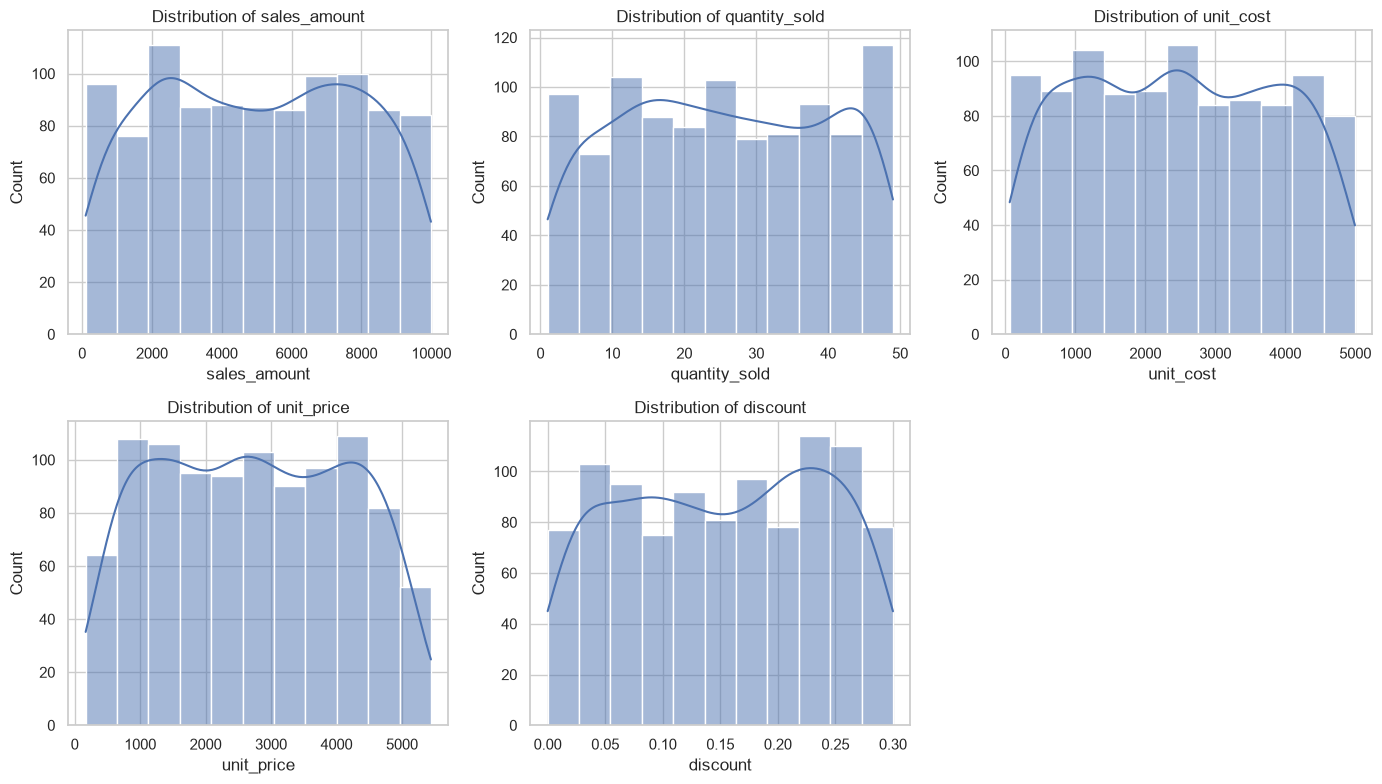

In [57]:
# Task 8: Univariate analysis
sns.set_theme(style="whitegrid")

num_plot_cols = ["sales_amount", "quantity_sold", "unit_cost", "unit_price", "discount"]
cat_plot_cols = ["region", "product_category", "customer_type", "payment_method", "sales_channel"]

# 1) histogram + KDE for numerical columns
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_plot_cols):
    sns.histplot(clean[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

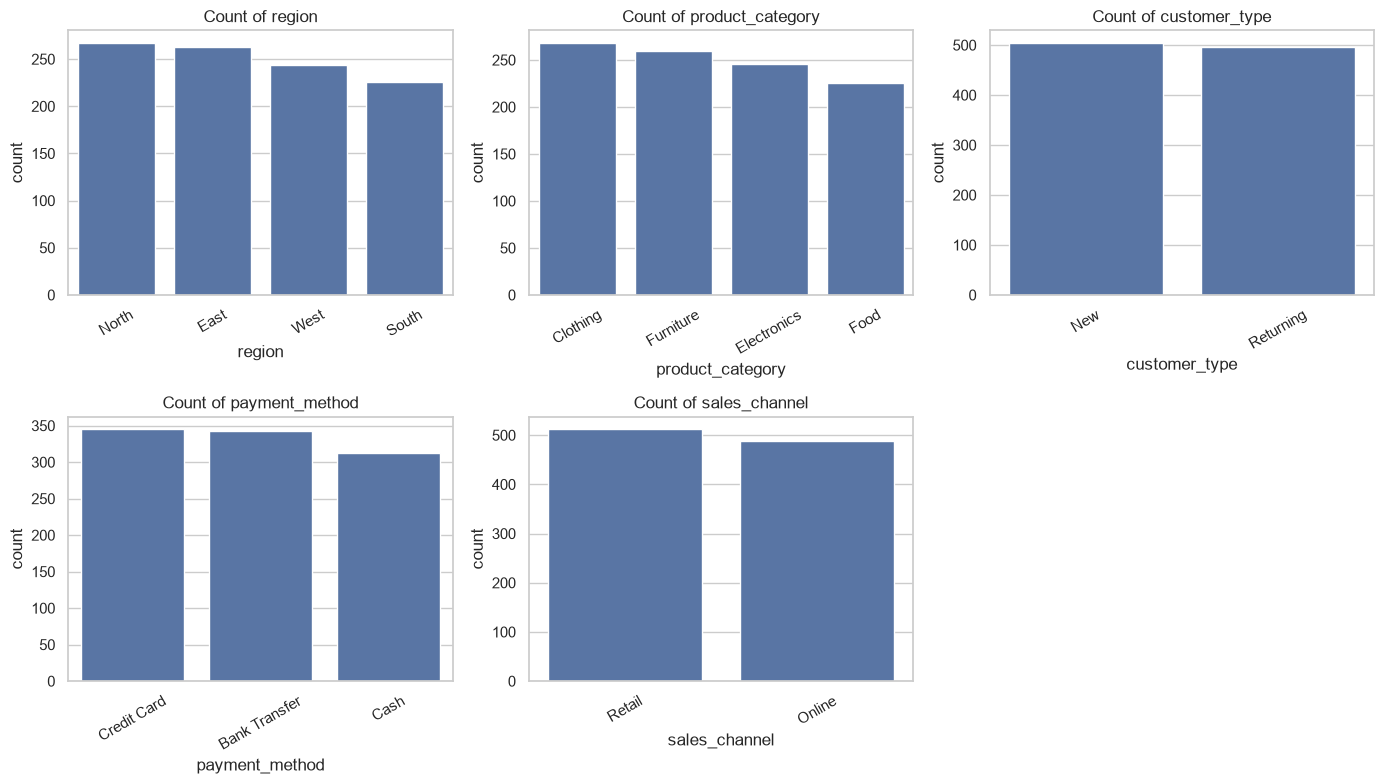

In [58]:

# 2) count plots for categorical columns
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cat_plot_cols):
    sns.countplot(data=clean, x=col, ax=axes[i], order=clean[col].value_counts().index)
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis="x", rotation=30)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

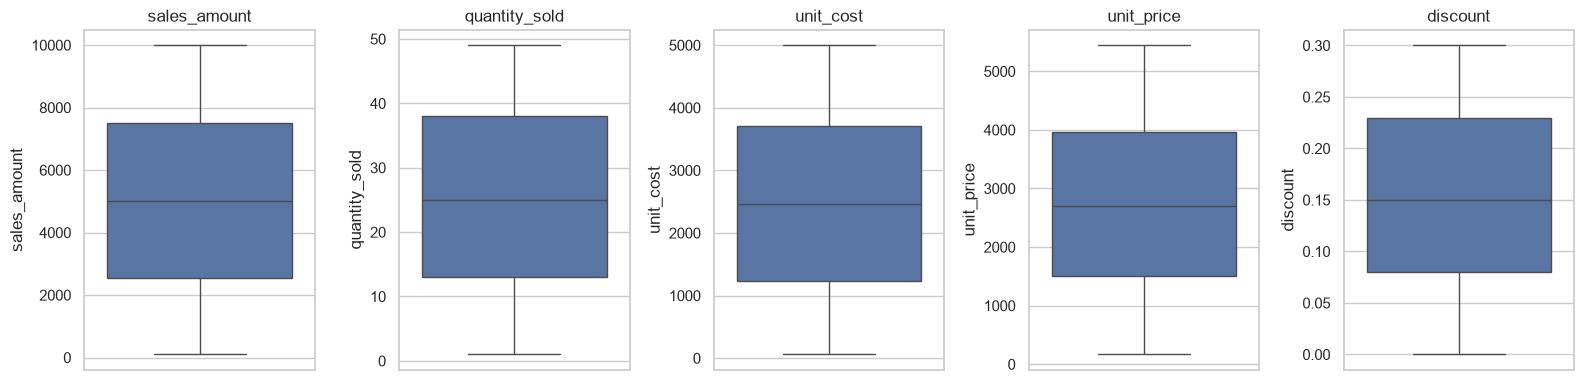

In [59]:
# 3) boxplots for outliers
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, col in enumerate(num_plot_cols):
    sns.boxplot(y=clean[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

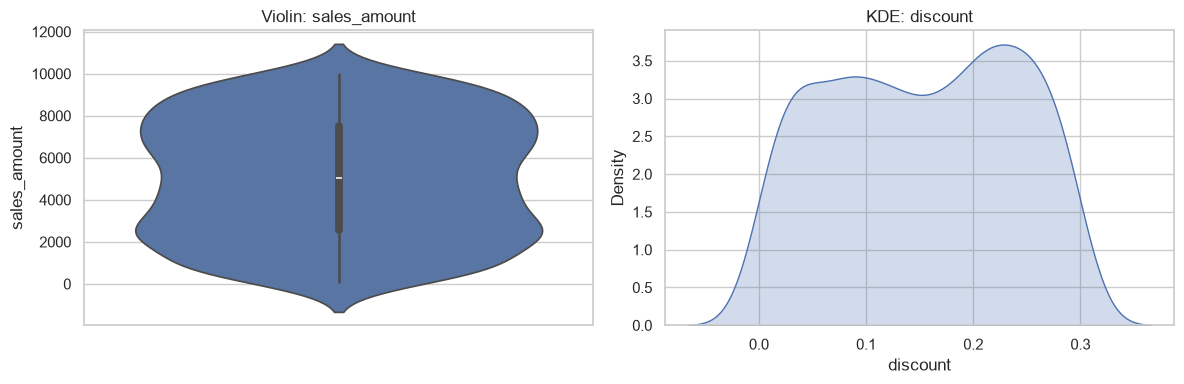

In [60]:
# charts from lectures
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.violinplot(y=clean["sales_amount"], ax=axes[0])
axes[0].set_title("Violin: sales_amount")
sns.kdeplot(clean["discount"], fill=True, ax=axes[1])
axes[1].set_title("KDE: discount")
plt.tight_layout()
plt.show()

### Task 9: Bivariate Analysis
1. Numerical vs Numerical:
   - Scatter plot
   - Correlation heatmap
2. Categorical vs Numerical:
   - Bar plot
   - Box plot
3. Show every chart possible being shown in matplotlib and Seaborn lectures for bivariate as well.

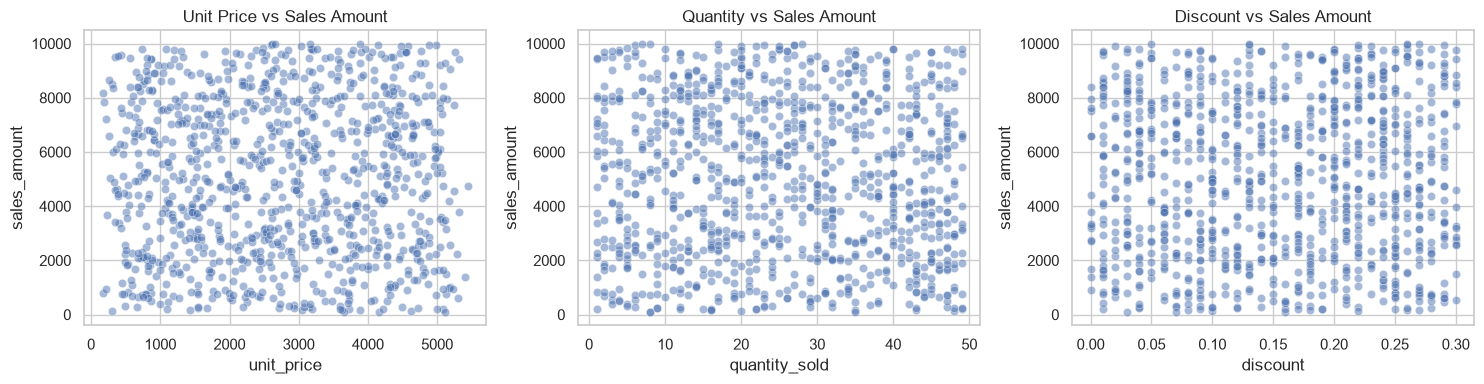

In [61]:
# Task 9: Bivariate analysis

# numerical vs numerical — scatter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=clean, x="unit_price", y="sales_amount", ax=axes[0], alpha=0.5)
axes[0].set_title("Unit Price vs Sales Amount")
sns.scatterplot(data=clean, x="quantity_sold", y="sales_amount", ax=axes[1], alpha=0.5)
axes[1].set_title("Quantity vs Sales Amount")
sns.scatterplot(data=clean, x="discount", y="sales_amount", ax=axes[2], alpha=0.5)
axes[2].set_title("Discount vs Sales Amount")
plt.tight_layout()
plt.show()

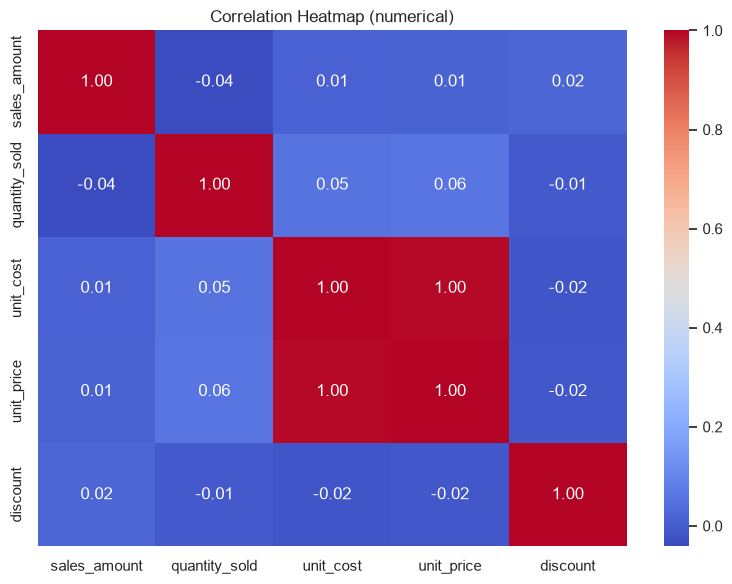

In [62]:

# correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(clean[num_plot_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (numerical)")
plt.tight_layout()
plt.show()

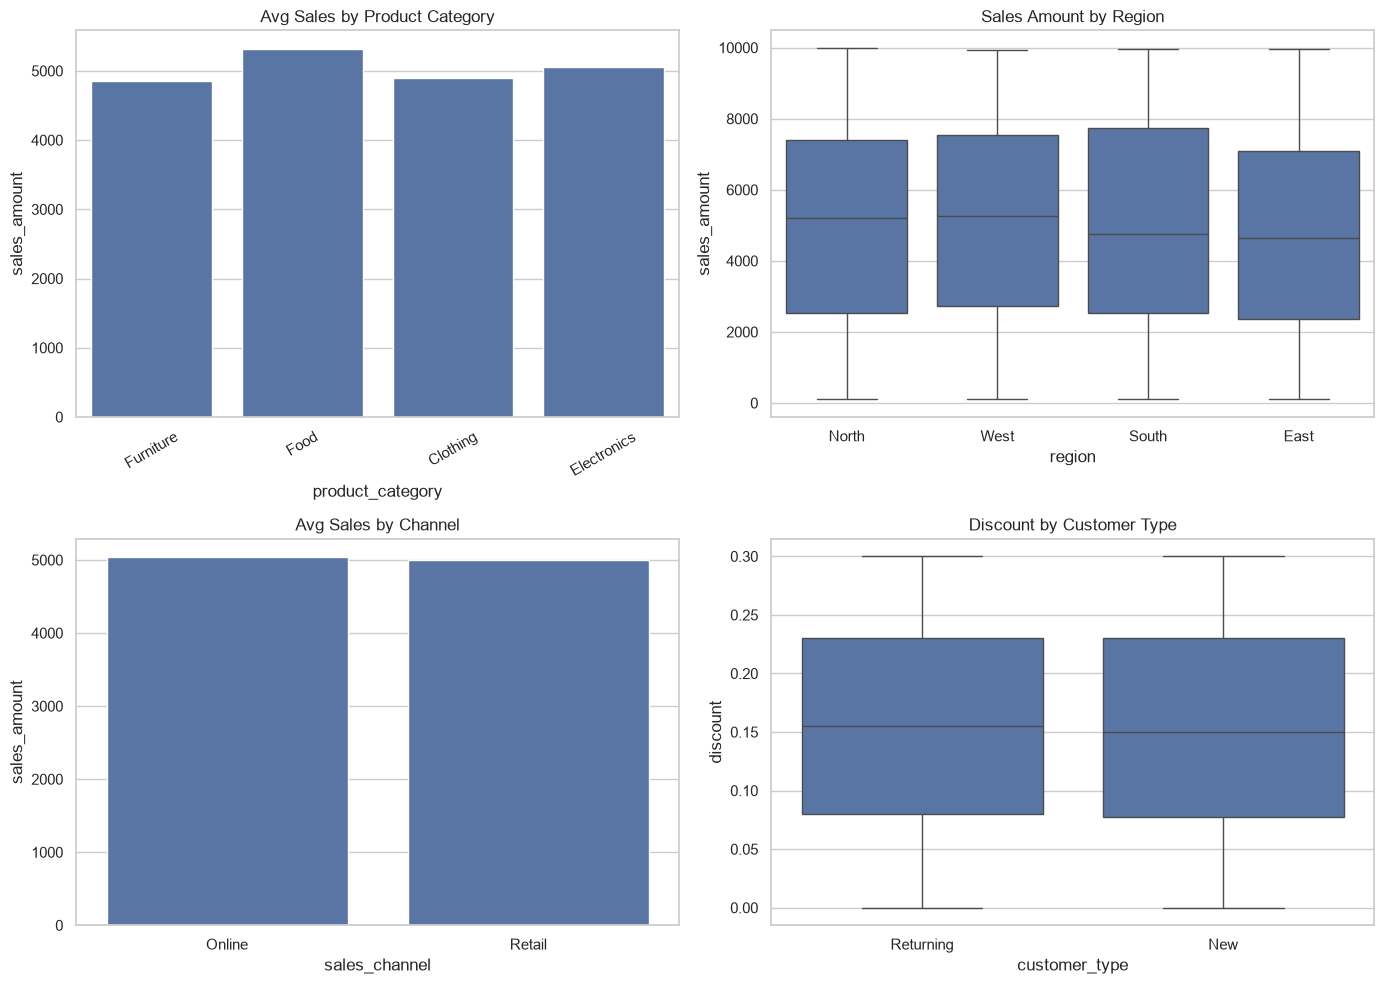

In [63]:
# categorical vs numerical — bar + box
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=clean, x="product_category", y="sales_amount", ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title("Avg Sales by Product Category")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.boxplot(data=clean, x="region", y="sales_amount", ax=axes[0, 1])
axes[0, 1].set_title("Sales Amount by Region")

sns.barplot(data=clean, x="sales_channel", y="sales_amount", ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("Avg Sales by Channel")

sns.boxplot(data=clean, x="customer_type", y="discount", ax=axes[1, 1])
axes[1, 1].set_title("Discount by Customer Type")
plt.tight_layout()
plt.show()


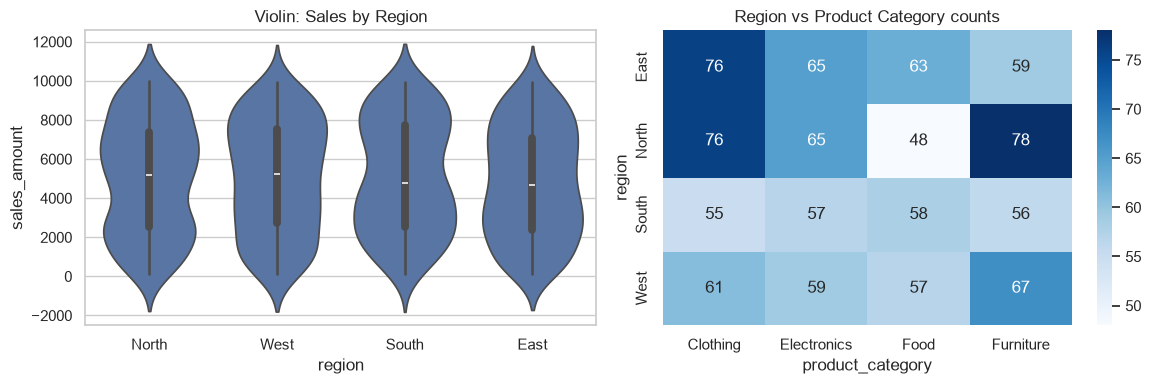

In [64]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.violinplot(data=clean, x="region", y="sales_amount", ax=axes[0])
axes[0].set_title("Violin: Sales by Region")
sns.heatmap(
    pd.crosstab(clean["region"], clean["product_category"]),
    annot=True, fmt="d", cmap="Blues", ax=axes[1]
)
axes[1].set_title("Region vs Product Category counts")
plt.tight_layout()
plt.show()

### Task 10: Insights & Observations
Write at least 5 insights, such as:
- Patterns
- Outliers
- Relationships
- Data quality issues

_(Write your insights in the markdown cell below)_

#### Insights

1. Looking at the sales amounts, they’re pretty spread out (around 100 to ~10k). I was expecting most sales to sit in one range, but they don’t — so “average sale” alone doesn’t tell you much.

2. Unit price and unit cost look related on the heatmap. I didn’t fully trust correlation at first, but after plotting it made sense — higher cost products usually have higher prices.

3. Quantity vs sales amount confused me a bit. I thought more quantity = more sales every time, but the scatter is messy because expensive items can sell few units and still make money.

4. Discount mostly stays between 0 and 0.3. Boxplots helped me see that better than just looking at describe(). Still getting used to reading boxplots for outliers though.

5. This dataset was actually clean already (no nulls / dupes). So Task 6 felt a bit like practice code. The useful part for me was renaming columns and converting Sale_Date to datetime — I keep forgetting dates come in as strings.

6. Sales look different by category / region / channel in the bar and box plots. Not sure how big the differences really are yet, but enough that I’d keep those columns if I build a model later.